In [1]:
import pandas as pd
import numpy as np

data = pd.read_csv(r'appian-x-iit-madras-hackathon-april-2025\train.csv')
test = pd.read_csv(r'appian-x-iit-madras-hackathon-april-2025\test.csv')

data.replace('Alone', 'Single', inplace=True)
test.replace('Absurd', 'Single', inplace=True)
data.replace('YOLO', 'Single', inplace=True)
test.replace('YOLO', 'Single', inplace=True)
# test.replace('Alone', 'Single', inplace=True)
# data.replace('Together', 'Married', inplace=True)
# test.replace('Together', 'Married', inplace=True)

# test.replace('Basic', '2n Cycle', inplace=True)
# data.replace('Basic', '2n Cycle', inplace=True)
# test.replace('Widow', 'Divorced', inplace=True)
# data.replace('Widow', 'Divorced', inplace=True)

data['Dt_Customer_1'] = pd.to_datetime(data['Dt_Customer'],format='mixed')
data['Dt_Customer_1'] = data['Dt_Customer_1']-min(data['Dt_Customer_1'])
data['Dates']=data['Dt_Customer_1'].dt.days

test['Dt_Customer_1'] = pd.to_datetime(test['Dt_Customer'],format='mixed')
test['Dt_Customer_1'] = test['Dt_Customer_1']-min(test['Dt_Customer_1'])
test['Dates']=test['Dt_Customer_1'].dt.days
Education = {}
Marital_status = {}
A = data['Education'].unique()
B = data['Marital_Status'].unique()
# A = test['Education'].unique()
# B = test['Marital_Status'].unique()
for i, category in enumerate(A):
    l = [0]*len(A)
    l[i] = 1
    print(f"{i}: {category}")
    Education[category] = i
for i, category in enumerate(B):
    l = [0]*len(B)
    l[i] = 1
    print(f"{i}: {category}")
    Marital_status[category] = i
data['Education'] = data['Education'].map(Education)
test['Education'] = test['Education'].map(Education)
data['Marital_Status'] = data['Marital_Status'].map(Marital_status)
test['Marital_Status'] = test['Marital_Status'].map(Marital_status)

# data = pd.get_dummies(data, columns=['Marital_Status', 'Education'], drop_first=True)
# test = pd.get_dummies(test, columns=['Marital_Status', 'Education'], drop_first=True)

0: Graduation
1: PhD
2: Master
3: Basic
4: 2n Cycle
0: Single
1: Together
2: Married
3: Divorced
4: Widow


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype          
---  ------               --------------  -----          
 0   ID                   1567 non-null   int64          
 1   Year_Birth           1567 non-null   int64          
 2   Education            1567 non-null   int64          
 3   Marital_Status       1567 non-null   int64          
 4   Income               1550 non-null   float64        
 5   Kidhome              1567 non-null   int64          
 6   Teenhome             1567 non-null   int64          
 7   Dt_Customer          1567 non-null   object         
 8   Recency              1567 non-null   int64          
 9   MntWines             1544 non-null   float64        
 10  MntFruits            1567 non-null   int64          
 11  MntMeatProducts      1561 non-null   float64        
 12  MntFishProducts      1567 non-null   int64          
 13  MntSweetProducts  

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import numpy as np

categorical_cols = ['Education', 'Marital_Status']
numerical_cols = [
    'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'Complain',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',
    'AcceptedCmp5', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth', 'Dates'
]
lists = [
    'Year_Birth',
    'Income',
    'Kidhome',
    'Teenhome',
    'Dates',
    'Recency',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumDealsPurchases',
    'NumWebVisitsMonth',
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Complain',
    # 'Marital_Status_Married',
    # 'Marital_Status_Single',
    # 'Education_Graduation',
    # 'Education_Master',
    # 'Education_PhD',
    'Marital_Status',
    'Education'
    # 'Target'
]
import torch
from torch.utils.data import Dataset

class CustomerDataset(Dataset):
    def __init__(self, df, feature_cols, target_col='Target'):
        self.X = df[feature_cols].values.astype('float32')
        self.y = df[target_col].values.astype('float32')

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {
            'features': torch.tensor(self.X[idx], dtype=torch.float),
            'target': torch.tensor(self.y[idx], dtype=torch.float)
        }
        # return torch.tensor(self.X[idx], dtype=torch.float), torch.tensor(self.y[idx], dtype=torch.float)

means = data.mean(numeric_only=True)
default_values = means[lists[:-2]]

In [4]:
dataset = CustomerDataset(data, lists, target_col='Target')

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ImputationLayer(nn.Module):
    def __init__(self, default_values):
        super(ImputationLayer, self).__init__()
        self.impute = nn.Parameter(torch.tensor(default_values, dtype=torch.float32), requires_grad=True)

    def forward(self, x):
        mask = torch.isnan(x)
        x[mask] = self.impute.expand(x.shape[0], -1)[mask]
        return x

class TrainableScaler(nn.Module):
    def __init__(self, num_features):
        super(TrainableScaler, self).__init__()
        self.mean = nn.Parameter(torch.zeros(num_features))
        self.std = nn.Parameter(torch.ones(num_features))

    def forward(self, x):
        return (x - self.mean) / (self.std + 1e-6)

class MarketResearchModel(nn.Module):
    def __init__(self, num_numeric_features, emb_sizes = [3,4], layers_list=[64, 32, 1], default_values=default_values, drop = 0.2):
        super(MarketResearchModel, self).__init__()

        # Imputation and scaling layers
        self.imputer = ImputationLayer(default_values)  # Replace with actual means
        self.scaler = TrainableScaler(num_features=num_numeric_features)

        # Embedding layers
        self.embedding_1 = nn.Embedding(num_embeddings=emb_sizes[0], embedding_dim=10)  # for class feature -6 to -3
        self.embedding_2 = nn.Embedding(num_embeddings=emb_sizes[1], embedding_dim=10)  # for class feature -3 to -1

        # Input size for FFN
        input_size = num_numeric_features + 20

        # Build feedforward layers dynamically
        layers = []
        in_dim = input_size
        for out_dim in layers_list:
            layers.append(nn.Linear(in_dim, out_dim))
            if out_dim != 1:
                layers.append(nn.BatchNorm1d(out_dim))
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(drop))
            in_dim = out_dim
        if layers_list[-1] != 1:
            layers.append(nn.Linear(in_dim, 1))
        # layers.append(nn.Sigmoid())

        self.ff = nn.Sequential(*layers)

    def forward(self, x):
        x_numeric = x[:, :-2]
        # x_cat1 = x[:, -5:-3].long()
        # x_cat2 = x[:, -3:-1].long()
        x_cat1 = x[:,-2:-1].long()
        x_cat2 = x[:,-1:].long()
        # print(x_numeric.shape, x_cat1.shape, x_cat2.shape)
        x_numeric = self.imputer(x_numeric)
        x_numeric = self.scaler(x_numeric)

        emb1 = self.embedding_1(x_cat1).squeeze(1)
        emb2 = self.embedding_2(x_cat2).squeeze(1)
        # print(emb1.shape, emb2.shape, x_numeric.shape)
        x = torch.cat([x_numeric, emb1, emb2], dim=1)
        return self.ff(x).squeeze(1)
import torch
import torch.nn as nn
import torch.nn.functional as F

class GLULayer(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GLULayer, self).__init__()
        self.fc = nn.Linear(input_dim, output_dim * 2)
        self.bn = nn.BatchNorm1d(output_dim * 2)

    def forward(self, x):
        x = self.bn(self.fc(x))
        out, gate = x.chunk(2, dim=-1)
        return out * torch.sigmoid(gate)

class FeatureTransformerBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.bn = nn.BatchNorm1d(dim)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        res = x
        x = F.relu(self.bn(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return F.relu(x + res)

class TabInspiredMarketModel(nn.Module):
    def __init__(
        self,
        num_numeric_features,
        emb_sizes=[3,4],
        default_values=default_values,
        hidden_dim=128,
        depth=4,
        layers_list=[64,32,1],
        drop=0.6
    ):
        super(TabInspiredMarketModel, self).__init__()

        # Imputation + scaling
        self.imputer = ImputationLayer(default_values)
        self.scaler  = TrainableScaler(num_features=num_numeric_features)

        # Embeddings
        self.embedding_1 = nn.Embedding(emb_sizes[0], 5)
        self.embedding_2 = nn.Embedding(emb_sizes[1], 5)

        # Initial GLU block
        input_dim = num_numeric_features + 10
        self.glu_layer = GLULayer(input_dim, hidden_dim)

        # TabNet‑style transformer blocks
        self.transformer_blocks = nn.Sequential(
            *[FeatureTransformerBlock(hidden_dim) for _ in range(depth)]
        )

        # Dynamically built FF head
        ff_layers = []
        in_dim = hidden_dim
        for out_dim in layers_list:
            ff_layers.append(nn.Linear(in_dim, out_dim))
            if out_dim != 1:
                ff_layers.append(nn.BatchNorm1d(out_dim))
                ff_layers.append(nn.ReLU())
                ff_layers.append(nn.Dropout(drop))
            in_dim = out_dim
        # if the last layer isn’t single‑unit, add one more
        if layers_list[-1] != 1:
            ff_layers.append(nn.Linear(in_dim, 1))
        # ff_layers.append(nn.Sigmoid())

        self.output = nn.Sequential(*ff_layers)

    def forward(self, x):
        # split numeric / cat
        x_num  = x[:, :-2]
        cat1   = x[:, -2:-1].long()
        cat2   = x[:, -1:  ].long()

        # impute + scale
        x_num = self.imputer(x_num)
        x_num = self.scaler(x_num)

        # embed cats
        e1 = self.embedding_1(cat1).squeeze(1)
        e2 = self.embedding_2(cat2).squeeze(1)

        # concat
        x = torch.cat([x_num, e1, e2], dim=1)

        # GLU + transformer blocks
        x = self.glu_layer(x)
        x = self.transformer_blocks(x)

        # final head
        return self.output(x).squeeze(1)

class TabInspiredMarketModel(nn.Module):
    def __init__(
        self,
        num_numeric_features,
        emb_sizes=[3,4],
        default_values=default_values,
        hidden_dim=128,
        depth=4,
        layers_list=[64,32,1],
        drop=0.3,
        n_heads=8
    ):
        super().__init__()

        # 1) Imputation & Scaling
        self.imputer = ImputationLayer(default_values)
        self.scaler  = TrainableScaler(num_features=num_numeric_features)

        # 2) Categoricals → Embeddings
        self.embedding_1 = nn.Embedding(emb_sizes[0], 5)
        self.embedding_2 = nn.Embedding(emb_sizes[1], 5)

        # 3) Project each scalar feature → hidden_dim token
        self.num_proj  = nn.Linear(1,     hidden_dim)
        self.cat_proj1 = nn.Linear(5,     hidden_dim)
        self.cat_proj2 = nn.Linear(5,     hidden_dim)

        # 4) Self‑Attention across the (N_numeric + 2) tokens
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=n_heads,
            dropout=drop,
            batch_first=False  # nn.MultiheadAttention defaults to (seq_len, batch, embed_dim)
        )

        # 5) GLU + TabNet‑style blocks
        self.glu_layer         = GLULayer(hidden_dim, hidden_dim)
        self.transformer_blocks = nn.Sequential(
            *[FeatureTransformerBlock(hidden_dim) for _ in range(depth)]
        )

        # 6) Dynamically built FFN head
        ff_layers = []
        in_dim = hidden_dim
        for out_dim in layers_list:
            ff_layers.append(nn.Linear(in_dim, out_dim))
            if out_dim != 1:
                ff_layers.append(nn.BatchNorm1d(out_dim))
                ff_layers.append(nn.ReLU())
                ff_layers.append(nn.Dropout(drop))
            in_dim = out_dim
        if layers_list[-1] != 1:
            ff_layers.append(nn.Linear(in_dim, 1))
        self.output = nn.Sequential(*ff_layers)

    def forward(self, x):
        # Split numeric vs. categorical indices
        x_num = x[:, :-2]                     # [B, N_num]
        cat1  = x[:, -2:-1].long()            # [B, 1]
        cat2  = x[:, -1:  ].long()            # [B, 1]

        # 1) Impute & scale
        x_num = self.imputer(x_num)           # [B, N_num]
        x_num = self.scaler(x_num)            # [B, N_num]

        # 2) Embed categories
        e1 = self.embedding_1(cat1).squeeze(1)  # [B, 5]
        e2 = self.embedding_2(cat2).squeeze(1)  # [B, 5]

        # 3) Build token sequence
        num_tokens = self.num_proj(x_num.unsqueeze(-1))  # [B, N_num, H]
        c1_token   = self.cat_proj1(e1).unsqueeze(1)     # [B, 1, H]
        c2_token   = self.cat_proj2(e2).unsqueeze(1)     # [B, 1, H]

        tokens = torch.cat([num_tokens, c1_token, c2_token], dim=1)  # [B, N_num+2, H]
        tokens_t = tokens.transpose(0, 1)                            # [seq_len, B, H]

        # 4) Self-attention
        attn_out, _ = self.attention(tokens_t, tokens_t, tokens_t)  # [seq_len, B, H]
        x = attn_out.mean(dim=0)                                    # [B, H]

        # 5) GLU + Transformer blocks
        x = self.glu_layer(x)                                       # [B, H]
        x = self.transformer_blocks(x)                              # [B, H]

        # 6) Final FF head
        return self.output(x).squeeze(1)                            # [B]


In [53]:
MarketResearchModel = TabInspiredMarketModel

In [54]:
MarketResearchModel.__init__

<function __main__.TabInspiredMarketModel.__init__(self, num_numeric_features, emb_sizes=[3, 4], default_values=Year_Birth              1968.838545
Income                 52024.465806
Kidhome                    0.449904
Teenhome                   0.499681
Dates                    549.746011
Recency                   49.345884
MntWines                 304.301813
MntFruits                 25.941289
MntMeatProducts          165.313901
MntFishProducts           37.271219
MntSweetProducts          27.125080
MntGoldProds              44.187781
NumWebPurchases            4.032546
NumCatalogPurchases        2.674537
NumStorePurchases          5.776005
NumDealsPurchases          2.332482
NumWebVisitsMonth          5.325463
AcceptedCmp1               0.063178
AcceptedCmp2               0.012125
AcceptedCmp3               0.072112
AcceptedCmp4               0.076579
AcceptedCmp5               0.070198
Complain                   0.010211
dtype: float64, hidden_dim=128, depth=4, layers_list=[64, 32

In [55]:
means = data.mean(numeric_only=True)
default_values = means[lists[:-2]]
model = MarketResearchModel(num_numeric_features=len(lists)-2, emb_sizes=[3,4], layers_list=[64, 32, 1], default_values=default_values).to('cuda')

In [56]:
from torchinfo import summary


summary(model, input_size=(3, len(lists)), col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
TabInspiredMarketModel                   [3, 25]                   [3]                       --                        --                        --
├─ImputationLayer: 1-1                   [3, 23]                   [3, 23]                   23                        --                        --
├─TrainableScaler: 1-2                   [3, 23]                   [3, 23]                   46                        --                        --
├─Embedding: 1-3                         [3, 1]                    [3, 1, 5]                 15                        --                        45
├─Embedding: 1-4                         [3, 1]                    [3, 1, 5]                 20                        --                        60
├─Linear: 1-5                            [3, 23, 1]                [3, 23, 128]              256         

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, random_split

# Set random seed
torch.manual_seed(42)

# --- Training & Evaluation ---
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in dataloader:
        x_all, y = batch["features"], batch["target"]
        x = x_all[:, :-2]
        cat1 = x_all[:, -2].long()
        cat2 = x_all[:, -1].long()
        x, y, cat1, cat2 = x.to(device), y.to(device), cat1.to(device), cat2.to(device)
        x_all = x_all.to(device)
        optimizer.zero_grad()
        preds = model(x_all)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(dataloader.dataset)

def evaluate(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            x_all, y = batch["features"], batch["target"]
            x = x_all[:, :-2]
            cat1 = x_all[:, -2].long()
            cat2 = x_all[:, -1].long()
            x, y, cat1, cat2 = x.to(device), y.to(device), cat1.to(device), cat2.to(device)
            x_all = x_all.to(device)
            pred = model(x_all)
            all_preds.append(pred.cpu())
            all_labels.append(y.cpu())

    preds = torch.cat(all_preds) > 0.5
    labels = torch.cat(all_labels)
    return accuracy_score(labels.numpy(), preds.numpy())

# --- Hyperparameter Tuning ---
def run_tuning(dataset, emb_sizes, param_grid, device='cuda' if torch.cuda.is_available() else 'cpu'):
    best_acc = 0
    best_model_state = None
    best_config = None

    val_len = int(0.2 * len(dataset))
    train_len = len(dataset) - val_len
    train_ds, val_ds = random_split(dataset, [train_len, val_len])

    for config in ParameterGrid(param_grid):
        print(f"\nTraining config: {config}")
        train_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=config['batch_size'])
        model = MarketResearchModel(
            num_numeric_features=dataset[0]["features"].shape[0] - 2,
            emb_sizes=emb_sizes,
            layers_list=config['layers_list']
        ).to(device)
        # print(dataset[0]["features"].shape[0] - 2, emb_sizes, config['layers_list'])
        optimizer = optim.Adam(model.parameters(), lr=config['lr'])
        criterion = nn.BCELoss()

        for epoch in range(config['epochs']):
            train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
            val_acc = evaluate(model, val_loader, device)
            print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f} | Val Acc = {val_acc:.4f}")

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_state = model.state_dict()
            best_config = config

    print(f"\nBest Config: {best_config} | Best Validation Accuracy: {best_acc:.4f}")
    return best_model_state, best_config

# --- Example Run ---
param_grid = {
    'lr': [1e-3, 5e-4, 1e-4],                          # Learning rates
    'batch_size': [32, 64, 128],                       # Batch sizes
    'layers_list': [                                   # Network depths
        [64, 32],
        [128, 64, 32],
        [256, 128, 64, 32],
        [128, 128, 64, 32]
    ],
    'epochs': [15, 25],                                # Training duration
}

# To run: best_state, best_params = run_tuning(dataset, emb_sizes=[3, 4], param_grid=param_grid)

KeyboardInterrupt: 

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, random_split
import warnings
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
warnings.filterwarnings("ignore", category=FutureWarning)

# Set random seed
torch.manual_seed(42)


# Suppose your DataFrame is df and your binary target column is 'Target'
y = data['Target'].values

# Compute weights for each class label (0 and 1)
classes = np.unique(y)
class_weights = compute_class_weight('balanced', classes=classes, y=y)
w0, w1 = class_weights
# --- Training & Evaluation ---
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in dataloader:
        x_all, y = batch["features"], batch["target"]
        x = x_all[:, :-2]
        cat1 = x_all[:, -2].long()
        cat2 = x_all[:, -1].long()
        x, y, cat1, cat2 = x.to(device), y.to(device), cat1.to(device), cat2.to(device)
        x_all = x_all.to(device)
        optimizer.zero_grad()
        preds = model(x_all)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss

# Reuse evaluate for both train and validation

def evaluate(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            x_all, y = batch["features"], batch["target"]
            x = x_all[:, :-2]
            cat1 = x_all[:, -2].long()
            cat2 = x_all[:, -1].long()
            x, y, cat1, cat2 = x.to(device), y.to(device), cat1.to(device), cat2.to(device)
            x_all = x_all.to(device)
            pred = model(x_all)
            # Apply sigmoid activation to get probabilities
            pred = torch.sigmoid(pred)
            all_preds.append(pred.cpu())
            all_labels.append(y.cpu())
    preds = torch.cat(all_preds) > 0.5
    labels = torch.cat(all_labels)
    return accuracy_score(labels.numpy(), preds.numpy())

# --- Hyperparameter Tuning ---
def run_tuning(dataset, emb_sizes, param_grid, device='cuda' if torch.cuda.is_available() else 'cpu'):
    best_global_score = 0
    best_model_state = None
    best_config = None

    val_len = int(0.2 * len(dataset))
    train_len = len(dataset) - val_len
    train_ds, val_ds = random_split(dataset, [train_len, val_len])

    for config in ParameterGrid(param_grid):
        print(f"\nTraining config: {config}")
        train_loader = DataLoader(train_ds, batch_size=config['batch_size'], shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=config['batch_size'])

        model = MarketResearchModel(
            num_numeric_features=dataset[0]["features"].shape[0] - 2,
            emb_sizes=emb_sizes,
            layers_list=config['layers_list']
        ).to(device)

        optimizer = optim.Adam(model.parameters(), lr=config['lr'])
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(w1/w0).to(device))

        best_config_score = 0
        for epoch in range(config['epochs']):
            train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
            train_acc = evaluate(model, train_loader, device)
            val_acc = evaluate(model, val_loader, device)
            epoch_score = min(train_acc, val_acc)
            best_config_score = max(best_config_score, epoch_score)
            # print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f} | Min Acc={epoch_score:.4f}")
            if epoch_score > best_global_score:
                best_global_score = best_config_score
                best_model_state = model.state_dict()
                best_config = config

        print(f"Best Min(train, val) accuracy for config: {best_config_score:.4f}")



    print(f"\nBest Config: {best_config} | Best Min Acc: {best_global_score:.4f}")
    return best_model_state, best_config

# --- Example Run ---
param_grid = {
    'lr': [1e-3, 1e-2],                          # Learning rates
    'batch_size': [32, 64, 128],                       # Batch sizes
    'layers_list': [                                   # Network depths
        [64, 32],
        [128, 64, 32],
        [256, 128, 64, 32],
        [128, 128, 64, 32]
    ],
    'epochs': [25, 35],                                # Training duration
}

# To run: best_state, best_params = run_tuning(dataset, emb_sizes=[3, 4], param_grid=param_grid)

In [66]:
run_tuning(dataset, emb_sizes=[5, 5], param_grid=param_grid)


Training config: {'batch_size': 32, 'epochs': 25, 'layers_list': [64, 32], 'lr': 0.001}
Best Min(train, val) accuracy for config: 0.8083

Training config: {'batch_size': 32, 'epochs': 25, 'layers_list': [64, 32], 'lr': 0.01}
Best Min(train, val) accuracy for config: 0.7987

Training config: {'batch_size': 32, 'epochs': 25, 'layers_list': [128, 64, 32], 'lr': 0.001}
Best Min(train, val) accuracy for config: 0.7923

Training config: {'batch_size': 32, 'epochs': 25, 'layers_list': [128, 64, 32], 'lr': 0.01}
Best Min(train, val) accuracy for config: 0.7807

Training config: {'batch_size': 32, 'epochs': 25, 'layers_list': [256, 128, 64, 32], 'lr': 0.001}
Best Min(train, val) accuracy for config: 0.7987

Training config: {'batch_size': 32, 'epochs': 25, 'layers_list': [256, 128, 64, 32], 'lr': 0.01}
Best Min(train, val) accuracy for config: 0.7831

Training config: {'batch_size': 32, 'epochs': 25, 'layers_list': [128, 128, 64, 32], 'lr': 0.001}
Best Min(train, val) accuracy for config: 0.78

(OrderedDict([('imputer.impute',
               tensor([1.9688e+03, 5.2024e+04, 4.4990e-01, 4.9968e-01, 5.4975e+02, 4.9346e+01,
                       3.0460e+02, 2.5941e+01, 1.6541e+02, 3.7271e+01, 2.7125e+01, 4.4283e+01,
                       4.0325e+00, 2.6745e+00, 5.7760e+00, 2.3325e+00, 5.3255e+00, 6.3178e-02,
                       1.2125e-02, 7.2112e-02, 7.6579e-02, 7.0198e-02, 1.0211e-02],
                      device='cuda:0')),
              ('scaler.mean',
               tensor([-3.0499e-05, -1.0238e-06, -4.2948e-05, -2.2048e-03,  4.6394e-05,
                       -1.6666e-03,  5.8338e-05,  1.7489e-05,  3.7192e-05, -1.0846e-05,
                        6.0739e-05, -4.4894e-06,  1.9130e-03,  1.4218e-05, -3.3947e-05,
                       -1.9254e-04, -2.5995e-03, -2.0811e-03,  9.2507e-05,  2.1943e-02,
                       -4.3273e-03, -1.0172e-02, -6.3790e-05], device='cuda:0')),
              ('scaler.std',
               tensor([ 0.8879,  1.6519,  0.6460,  0.0257,  1.11

In [21]:
param_grid = {
    'lr': [1e-3, 5e-4, 1e-4],                          # Learning rates
    'batch_size': [32, 64, 128, 256],                       # Batch sizes
    'layers_list': [                                   # Network depths (shallow → deep)
        [64, 32],
        [128, 64, 32],
        [256, 128, 64, 32],
        [128, 128, 64, 32],
        [256, 256, 128, 64, 32],                       # New: deeper and wider
        [512, 256, 128, 64, 32],                       # New: even wider
        [512, 512, 256, 128, 64, 32],                  # New: deeper
        [1024, 512, 256, 128, 64, 32],                 # New: very deep
        [512, 512, 512, 256, 128, 64, 32],             # New: 7-layer net
    ],
    'epochs': [100],                                # Training duration
}
param_grid = {
    'lr': [1e-3, 5e-4, 1e-4],                          # Learning rates
    'batch_size': [64, 128, 256],
    'layers_list': [
        # Baseline and shallow
        [64, 32],
        [128, 64, 32],
        [256, 128, 64, 32],
        [128, 128, 64, 32],

        # Deeper & wider
        [256, 256, 128, 64, 32],
        [512, 256, 128, 64, 32],
        [512, 512, 256, 128, 64, 32],
        [1024, 512, 256, 128, 64, 32],
        [512, 512, 512, 256, 128, 64, 32],

        # 🧱 Bottleneck-style (wide → narrow → wide)
        [512, 256, 128, 256, 512],
        [256, 128, 64, 128, 256],

        # 🔻 Pyramidal (gradually reducing width)
        [1024, 512, 256, 128, 64, 32, 16],
        [512, 256, 128, 64, 32, 16],
        [256, 128, 64, 32, 16],

        # 🔺 Inverse pyramid (upscaling – not typical, but may help for expressive tasks)
        [64, 128, 256, 512],
        [32, 64, 128, 256, 512],

        # 🌀 Residual-style symmetry (no skips, just same-sized stages)
        [256, 256, 256, 256],
        [128, 256, 128, 256, 128],
        [512, 256, 128, 128, 256, 512],

        # 🪜 Steady downstep
        [1024, 512, 256, 128, 64, 32, 16, 8],

        # 🔁 Repeating block pattern
        [256, 128, 256, 128, 256, 128],
    ],
    'epochs': [250],
}

best_state, best_params = run_tuning(dataset, emb_sizes=[5, 5], param_grid=param_grid)


Training config: {'batch_size': 64, 'epochs': 250, 'layers_list': [64, 32], 'lr': 0.001}
Best Min(train, val) accuracy for config: 0.8371

Training config: {'batch_size': 64, 'epochs': 250, 'layers_list': [64, 32], 'lr': 0.0005}
Best Min(train, val) accuracy for config: 0.8371

Training config: {'batch_size': 64, 'epochs': 250, 'layers_list': [64, 32], 'lr': 0.0001}
Best Min(train, val) accuracy for config: 0.7955

Training config: {'batch_size': 64, 'epochs': 250, 'layers_list': [128, 64, 32], 'lr': 0.001}
Best Min(train, val) accuracy for config: 0.8435

Training config: {'batch_size': 64, 'epochs': 250, 'layers_list': [128, 64, 32], 'lr': 0.0005}
Best Min(train, val) accuracy for config: 0.8307

Training config: {'batch_size': 64, 'epochs': 250, 'layers_list': [128, 64, 32], 'lr': 0.0001}
Best Min(train, val) accuracy for config: 0.8051

Training config: {'batch_size': 64, 'epochs': 250, 'layers_list': [256, 128, 64, 32], 'lr': 0.001}
Best Min(train, val) accuracy for config: 0.837

KeyboardInterrupt: 

In [11]:
best_state = torch.load('best_state.pth')
best_params = torch.load('best_params.pth')

In [ ]:
torch.save(best_state, 'best_state.pth')
torch.save(best_params, 'best_params.pth')

In [ ]:
# Rebuild the model using best_config and load weights
device = 'cuda' if torch.cuda.is_available() else 'cpu'
best_model = MarketResearchModel(
    num_numeric_features=dataset[0]["features"].shape[0] - 2,
    emb_sizes=[3, 4],  # Use the same emb_sizes you used during tuning
    layers_list=best_params['layers_list']
).to(device)

# Load trained weights
best_model.load_state_dict(best_state)
best_model.eval()
test_set = CustomerDataset(test, lists, target_col='ID')
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

In [ ]:
MarketResearchModel = TabInspiredMarketModel


In [58]:
summary(model)

Layer (type:depth-idx)                             Param #
TabInspiredMarketModel                             --
├─ImputationLayer: 1-1                             23
├─TrainableScaler: 1-2                             46
├─Embedding: 1-3                                   25
├─Embedding: 1-4                                   25
├─Linear: 1-5                                      64
├─Linear: 1-6                                      192
├─Linear: 1-7                                      192
├─MultiheadAttention: 1-8                          3,168
│    └─NonDynamicallyQuantizableLinear: 2-1        1,056
├─GLULayer: 1-9                                    --
│    └─Linear: 2-2                                 2,112
│    └─BatchNorm1d: 2-3                            128
├─Sequential: 1-10                                 --
│    └─FeatureTransformerBlock: 2-4                --
│    │    └─Linear: 3-1                            1,056
│    │    └─Linear: 3-2                            1,056
│    

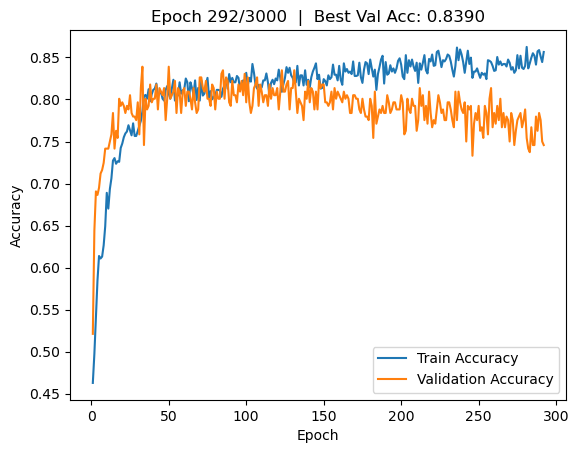

KeyboardInterrupt: 

In [12]:
# layers_list_now = [512,256,128,128,256,512]
# layers_list_now = [512, 256, 64, 256, 512]
# layers_list_now = [64, 32]
# # bt_size = 32
# bt_size = 128
# lr = 0.001
layers_list_now = best_params['layers_list']
bt_size = best_params['batch_size']
lr=best_params['lr']
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from altair import layer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from IPython.display import clear_output
# For progress bars (optional)
from tqdm import tqdm
train_acc_list = []
val_acc_list = []
best_val_acc = 0
# -----------------------------------------------------------------------------
# 1) Reproducibility & Device
# -----------------------------------------------------------------------------
torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# -----------------------------------------------------------------------------
# 2) Train/Validation Split
# -----------------------------------------------------------------------------
# `train` is your full DataFrame
train_df, val_df = train_test_split(data, test_size=0.15, random_state=42)

# -----------------------------------------------------------------------------
# 3) Datasets & Loaders
# -----------------------------------------------------------------------------
# `lists` is your list of feature columns in order; target_col='ID'
train_set = CustomerDataset(train_df, lists, target_col='Target')
val_set   = CustomerDataset(val_df,   lists, target_col='Target')

train_loader = DataLoader(train_set, batch_size=bt_size, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=bt_size, shuffle=False)

# -----------------------------------------------------------------------------
# 4) Model, Loss, Optimizer
# -----------------------------------------------------------------------------
model = MarketResearchModel(
    num_numeric_features=train_set[0]["features"].shape[0] - 2,
    emb_sizes=[5, 5],
    layers_list=layers_list_now,
    # depth=2,  # Set to 2 for the new model
    # hidden_dim=128
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(w1/w0).to(device))
optimizer = optim.Adam(model.parameters(), lr = lr)

# -----------------------------------------------------------------------------
# 5) Training Loop (inline, no helper funcs)
# -----------------------------------------------------------------------------
# epochs = best_params['epochs']
epochs = 3000  # Set to 100 epochs for training
higest_state = 0
for epoch in range(1, epochs + 1):
    # — Train —
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs} [Train]", leave=False):
        x_all = batch["features"].to(device)
        y_all = batch["target"].float().to(device)

        optimizer.zero_grad()
        outputs = model(x_all)
        loss = criterion(outputs, y_all)
        outputs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * y_all.size(0)
        preds = (outputs > 0.5).float()
        train_correct += (preds == y_all).sum().item()
        train_total += y_all.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total
    train_acc_list.append(train_acc)

    # — Validate —
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{epochs} [Val]  ", leave=False):
            x_all = batch["features"].to(device)
            y_all = batch["target"].float().to(device)

            outputs = model(x_all)
            loss = criterion(outputs, y_all)
            outputs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities
            val_loss += loss.item() * y_all.size(0)
            preds = (outputs > 0.5).float()
            val_correct += (preds == y_all).sum().item()
            val_total += y_all.size(0)
    
    val_loss /= val_total
    val_acc = val_correct / val_total
    val_acc_list.append(val_acc)
    if val_acc > best_val_acc:
        best_model_state = model.state_dict()
    best_val_acc = max(best_val_acc, val_acc)

    # Clear previous output and plot
    clear_output(wait=True)
    plt.figure()
    plt.plot(range(1, epoch + 1), train_acc_list, label='Train Accuracy')
    plt.plot(range(1, epoch + 1), val_acc_list, label='Validation Accuracy')
    plt.title(f'Epoch {epoch}/{epochs}  |  Best Val Acc: {best_val_acc:.4f}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Also print current and best in compact form
    # print(f'Epoch {epoch}/{epochs} → Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Best Val Acc: {best_val_acc:.4f}')
    # print(f"Epoch {epoch}/{epochs} → "
    #       f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
    #       f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

# -----------------------------------------------------------------------------
# 6) Save Final Model
# -----------------------------------------------------------------------------
torch.save(model.state_dict(), "final_best_model.pt")
print("✅ Model trained and saved to 'final_best_model.pt'")


In [15]:
model.load_state_dict(best_model_state)
test_set = CustomerDataset(test, lists, target_col='ID')
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)
best_model = model
best_model.eval()

MarketResearchModel(
  (imputer): ImputationLayer()
  (scaler): TrainableScaler()
  (embedding_1): Embedding(5, 10)
  (embedding_2): Embedding(5, 10)
  (ff): Sequential(
    (0): Linear(in_features=43, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.6, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.6, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.6, inplace=False)

In [16]:
IDs = []
Targets = []
for i in test_loader:
    x_all = i['features'].to(device)
    x_all = x_all.to(device)
    pred = best_model(x_all)
    pred = pred > 0.5
    pred = pred.int().cpu().numpy()
    Targets += pred.tolist()
    IDs += i['target'].tolist()
submission = pd.DataFrame({'ID': IDs, 'Target': Targets})
# comp = pd.read_csv(r'submission1.csv')
comp = pd.read_csv(r'MLP_embed-84.csv')
comp = comp.sort_values(by='ID', ignore_index=True)
submission = submission.sort_values(by='ID', ignore_index=True)
(comp['Target'] == submission['Target']).mean()  # Check accuracy of submission

0.9093610698365527

In [17]:
submission.to_csv(r'MLP_embed-83_2.csv', index=False)

In [255]:
import pandas as pd
import numpy as np

data2 = pd.read_csv(r'appian-x-iit-madras-hackathon-april-2025\train.csv')
test2 = pd.read_csv(r'appian-x-iit-madras-hackathon-april-2025\test.csv')

# data2.replace('Alone', 'Single', inplace=True)
# test2.replace('Absurd', 'Single', inplace=True)
# data2.replace('YOLO', 'Single', inplace=True)
# test2.replace('YOLO', 'Single', inplace=True)
# test2.replace('Alone', 'Single', inplace=True)
# data2.replace('Together', 'Married', inplace=True)
# test2.replace('Together', 'Married', inplace=True)

# test2.replace('Basic', '2n Cycle', inplace=True)
# data2.replace('Basic', '2n Cycle', inplace=True)
# test2.replace('Widow', 'Divorced', inplace=True)
# data2.replace('Widow', 'Divorced', inplace=True)

# data2['Dt_Customer_1'] = pd.to_datetime(data2['Dt_Customer'],format='mixed')
# data2['Dt_Customer_1'] = data2['Dt_Customer_1']-min(data2['Dt_Customer_1'])
# data2['Dates']=data2['Dt_Customer_1'].dt.days

# test2['Dt_Customer_1'] = pd.to_datetime(test2['Dt_Customer'],format='mixed')
# test2['Dt_Customer_1'] = test2['Dt_Customer_1']-min(test2['Dt_Customer_1'])
# test2['Dates']=test2['Dt_Customer_1'].dt.days
# Education = {}
# Marital_status = {}
# A = data2['Education'].unique()
# B = data2['Marital_Status'].unique()

# for i in range(len(A)):
#     Education[A[i]] = i
# for i in range(len(B)):
#     Marital_status[B[i]] = i
# data2['Education'] = data2['Education'].map(Education)
# data2['Marital_Status'] = data2['Marital_Status'].map(Marital_status)

# spend_cols = ['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']
# data2['TotalSpend']       = data2[spend_cols].sum(axis=1)
# for col in spend_cols:
#     data2[col + '_Pct']   = data2[col] / (data2['TotalSpend'] + 1e-6)

# data2['TotalAccepted']    = data2[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']].sum(axis=1)
# data2['DealAcceptanceRate']= data2['NumDealsPurchases'] / (data2['NumStorePurchases'] + data2['NumWebPurchases'] + data2['NumCatalogPurchases'] + 1e-6)

In [257]:
from re import X
from catboost import train


# # lists = [
# #     'Year_Birth',
# #     'Income',
# #     'Kidhome',
# #     'Teenhome',
# #     'Dates',
# #     'Recency',
# #     'MntWines',
# #     'MntFruits',
# #     'MntMeatProducts',
# #     'MntFishProducts',
# #     'MntSweetProducts',
# #     'MntGoldProds',
# #     'NumWebPurchases',
# #     'NumCatalogPurchases',
# #     'NumStorePurchases',
# #     'NumDealsPurchases',
# #     'NumWebVisitsMonth',
# #     'AcceptedCmp1',
# #     'AcceptedCmp2',
# #     'AcceptedCmp3',
# #     'AcceptedCmp4',
# #     'AcceptedCmp5',
# #     'Complain',
# #     # 'Marital_Status_Married',
# #     # 'Marital_Status_Single',
# #     # 'Education_Graduation',
# #     # 'Education_Master',
# #     # 'Education_PhD',
# #     'Marital_Status',
# #     'Education'
# #     # 'Target'
# # ]
# import pandas as pd

# # 1) Create the new features on your DataFrame (here called `data2`):
# data2 = data2.copy()
# data2['Age'] = 2025 - data2['Year_Birth']

# q1, q99 = data2['Income'].quantile([0.01, 0.99])
# data2['Income_clipped'] = data2['Income'].clip(q1, q99)
# data2['Income_log'] = np.log1p(data2['Income_clipped'])

# # If your “Dates” column is already a numeric “days since enrollment” use it directly;
# # otherwise convert a datetime:
# # data2['Dates'] = (pd.to_datetime('2025-04-18') - pd.to_datetime(data2['Dt_Customer'])).dt.days
# data2['Tenure'] = data2['Dates']  # assuming 'Dates' already gives days since enrollment

# # Total spend and spend percentages
# spend_cols = [
#     'MntWines','MntFruits','MntMeatProducts',
#     'MntFishProducts','MntSweetProducts','MntGoldProds'
# ]
# data2['TotalSpend'] = data2[spend_cols].sum(axis=1)
# for c in spend_cols:
#     data2[c + '_Pct'] = data2[c] / (data2['TotalSpend'] + 1e-6)

# # Campaign response rates
# cmp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
# data2['TotalAccepted']     = data2[cmp_cols].sum(axis=1)
# data2['DealAcceptanceRate']= data2['NumDealsPurchases'] / (
#     data2[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(axis=1) + 1e-6
# )

# # 2) Now define your new feature list (in the exact order you want):
# lists = [
#     # Demographics & tenure
#     'Age',
#     'Income_log',
#     'Kidhome',
#     'Teenhome',
#     'Tenure',
#     'Recency',
#     'Complain',

#     # Raw spends
#     *spend_cols,           # expands to the six spend columns
#     'TotalSpend',
#     *[c + '_Pct' for c in spend_cols],

#     # Web/store/catalog activity
#     'NumWebVisitsMonth',
#     'NumWebPurchases',
#     'NumCatalogPurchases',
#     'NumStorePurchases',

#     # Deal/campaign history
#     'NumDealsPurchases',
#     'DealAcceptanceRate',
#     *cmp_cols,             # the five AcceptedCmp# columns
#     'TotalAccepted',

#     # Categorical
#     'Marital_Status',
#     'Education'
# ]

from re import X
from catboost import train
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


def preprocess_appian(df, reference_date="2025-04-18"):
    df = df.copy()

    # 1) Parse enrollment date into components
    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True, errors='coerce')
    df['Enroll_Year'] = df['Dt_Customer'].dt.year
    df['Enroll_Month'] = df['Dt_Customer'].dt.month
    df['Enroll_DayOfWeek'] = df['Dt_Customer'].dt.dayofweek
    df['Enroll_Day'] = df['Dt_Customer'].dt.day

    # 2) Age at reference date
    ref = pd.to_datetime(reference_date)
    df['Age'] = ref.year - df['Year_Birth']
    q1, q99 = df['Age'].quantile([0.01, 0.99])
    df['Age'] = df['Age'].clip(q1, q99)

    # 3) Income preprocessing
    q1, q99 = df['Income'].quantile([0.01, 0.99])
    df['Income_clipped'] = df['Income'].clip(q1, q99)
    df['Income_log'] = np.log1p(df['Income_clipped'])
    df['Income_missing'] = df['Income'].isna().astype(int)

    # 4) Household composition
    df['Kids_total'] = df['Kidhome'] + df['Teenhome']
    df['Kid_ratio'] = df['Kidhome'] / (df['Kids_total'] + 1e-6)
    df['Teen_ratio'] = df['Teenhome'] / (df['Kids_total'] + 1e-6)

    # 5) Recency buckets
    df['Recency_bucket'] = pd.cut(
        df['Recency'],
        bins=[-1, 7, 30, 60, df['Recency'].max()],
        labels=False
    )

    # 6) Spending features & percentages
    spend_cols = [
        'MntWines', 'MntFruits', 'MntMeatProducts',
        'MntFishProducts', 'MntSweetProducts', 'MntGoldProds'
    ]
    df['TotalSpend'] = df[spend_cols].sum(axis=1)
    for c in spend_cols:
        df[c + '_Pct'] = df[c] / (df['TotalSpend'] + 1e-6)

    # 7) Purchase behavior
    df['TotalPurchases'] = (
        df['NumWebPurchases'] +
        df['NumCatalogPurchases'] +
        df['NumStorePurchases']
    )
    df['AvgSpend_per_Purchase'] = np.where(
        df['TotalPurchases'] > 0,
        df['TotalSpend'] / df['TotalPurchases'],
        0.0
    )
    df['Visits_per_Purchase'] = np.where(
        df['TotalPurchases'] > 0,
        df['NumWebVisitsMonth'] / df['TotalPurchases'],
        0.0
    )

    # 8) Campaign responsiveness
    cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
    df['TotalAccepted'] = df[cmp_cols].sum(axis=1)
    df['DealAcceptanceRate'] = np.where(
        df['TotalPurchases'] > 0,
        df['NumDealsPurchases'] / df['TotalPurchases'],
        0.0
    )

    # 9) Discount responsiveness
    df['Catalog_to_Total'] = df['NumCatalogPurchases'] / (df['TotalPurchases'] + 1e-6)
    df['Store_to_Total'] = df['NumStorePurchases'] / (df['TotalPurchases'] + 1e-6)
    df['Web_to_Total'] = df['NumWebPurchases'] / (df['TotalPurchases'] + 1e-6)

    # 10) Loyalty features
    df['Tenure'] = (ref - df['Dt_Customer']).dt.days
    df['Spend_per_Day'] = df['TotalSpend'] / (df['Tenure'] + 1e-6)

    # 11) Encode categorical features if needed
    df['Marital_Status'] = df['Marital_Status'].fillna('Unknown')
    df['Education'] = df['Education'].fillna('Unknown')

    # 12) Final feature list
    feature_cols = [
        'Enroll_Year', 'Enroll_Month', 'Enroll_DayOfWeek', 'Enroll_Day',
        'Age', 'Income_log', 'Income_missing', 'Recency', 'Recency_bucket', 'Complain',
        'Kids_total', 'Kid_ratio', 'Teen_ratio',
        *spend_cols, 'TotalSpend', *[c + '_Pct' for c in spend_cols],
        'TotalPurchases', 'AvgSpend_per_Purchase', 'Visits_per_Purchase',
        'NumDealsPurchases', 'DealAcceptanceRate', 'TotalAccepted',
        'NumWebVisitsMonth', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
        'Catalog_to_Total', 'Store_to_Total', 'Web_to_Total',
        'Tenure', 'Spend_per_Day',
        'Marital_Status', 'Education'
    ]
    cat_features = ['Marital_Status', 'Education']

    return df, feature_cols, cat_features


# Apply preprocessing
data2, lists, cat_features = preprocess_appian(data2)

# Train-test split
x = data2[lists].copy()
y = data2['Target'].copy()
X_train, X_val, y_train, y_val = train_test_split(
    x, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42)


[0]	eval-logloss:0.64986
[100]	eval-logloss:0.48145
[200]	eval-logloss:0.41236
[300]	eval-logloss:0.37754
[400]	eval-logloss:0.35789
[500]	eval-logloss:0.34446
[600]	eval-logloss:0.33543
[700]	eval-logloss:0.32918
[800]	eval-logloss:0.32453
[900]	eval-logloss:0.32150
[999]	eval-logloss:0.31919
0:	learn: 0.8063830	test: 0.7763578	best: 0.7763578 (0)	total: 31.5ms	remaining: 31.4s
100:	learn: 0.8744681	test: 0.8498403	best: 0.8498403 (90)	total: 5.85s	remaining: 52.1s
200:	learn: 0.8925532	test: 0.8402556	best: 0.8498403 (90)	total: 11.6s	remaining: 46.2s
300:	learn: 0.9095745	test: 0.8498403	best: 0.8658147 (268)	total: 16.8s	remaining: 39s
400:	learn: 0.9287234	test: 0.8562300	best: 0.8658147 (268)	total: 21.8s	remaining: 32.6s
500:	learn: 0.9436170	test: 0.8530351	best: 0.8658147 (268)	total: 27.5s	remaining: 27.4s
600:	learn: 0.9606383	test: 0.8530351	best: 0.8658147 (268)	total: 33.3s	remaining: 22.1s
700:	learn: 0.9670213	test: 0.8530351	best: 0.8658147 (268)	total: 39.3s	remaining

KeyError: 'train'

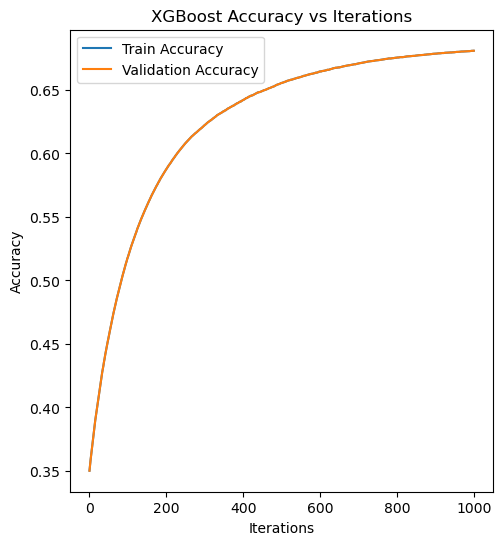

In [173]:
from sklearn import metrics
import xgboost as xgb
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier, Pool
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Create an instance of LabelEncoder
le = LabelEncoder()

# Step 1: Define and train CatBoost model (as in your example)
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool   = Pool(X_val,   y_val,   cat_features=cat_features)

# Compute class weights
X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()
X_test_encoded = X_test.copy()

for col in cat_features:
    X_train_encoded[col] = le.fit_transform(X_train_encoded[col])
    X_val_encoded[col] = le.transform(X_val_encoded[col])
    X_test_encoded[col] = le.transform(X_test_encoded[col])

# Step 2: Prepare data for XGBoost's xgb.train method
dtrain = xgb.DMatrix(X_train_encoded, label=y_train)
dval = xgb.DMatrix(X_val_encoded, label=y_val)

# XGBoost Parameters
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'learning_rate': 0.01,
    'max_depth': 2,
    'verbosity': 1,
}

# Track XGBoost's training performance using eval_set (validation set)
evals_result_xgb = {}  # To store metrics during training

# Train XGBoost model and capture eval results
num_round = 1000
bst = xgb.train(
    params, 
    dtrain, 
    num_round, 
    evals=[(dval, 'eval')],
    evals_result=evals_result_xgb,
    verbose_eval=100
)

# Step 3: Define and train CatBoost model (handle categorical features properly)
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    depth=2,
    cat_features=cat_features,  # Tell CatBoost which columns are categorical
    verbose=100,
    eval_metric='Accuracy',
)

# Track CatBoost's training performance
cat_train_metrics = cat_model.get_evals_result()

# Train CatBoost model
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val))

# Step 4: Generate predictions from both models
cat_preds_train = cat_model.predict(X_train)  # Predictions on training set
cat_preds_val = cat_model.predict(X_val)  # Predictions on validation set
xgb_preds_train = bst.predict(dtrain)  # Predictions on training set
xgb_preds_val = bst.predict(dval)  # Predictions on validation set

# Convert XGBoost's output to binary predictions
xgb_preds_train = (xgb_preds_train > 0.5).astype(int)
xgb_preds_val = (xgb_preds_val > 0.5).astype(int)

# Step 5: Evaluate both models' accuracy
cat_train_accuracy = accuracy_score(y_train, cat_preds_train)
cat_val_accuracy = accuracy_score(y_val, cat_preds_val)
xgb_train_accuracy = accuracy_score(y_train, xgb_preds_train)
xgb_val_accuracy = accuracy_score(y_val, xgb_preds_val)

print(f"CatBoost Train Accuracy: {cat_train_accuracy}")
print(f"CatBoost Validation Accuracy: {cat_val_accuracy}")
print(f"XGBoost Train Accuracy: {xgb_train_accuracy}")
print(f"XGBoost Validation Accuracy: {xgb_val_accuracy}")

# Step 6: Plot the training/validation metrics for both models
# XGBoost Metrics
# Step 6: Plot the training/validation metrics for both models
# XGBoost Metrics
xgb_train_accuracy_iter = [1 - x for x in evals_result_xgb['eval']['logloss']]  # Convert logloss to accuracy
xgb_val_accuracy_iter = [1 - x for x in evals_result_xgb['eval']['logloss']]  # Convert logloss to accuracy

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(len(xgb_train_accuracy_iter)), xgb_train_accuracy_iter, label='Train Accuracy')
plt.plot(range(len(xgb_val_accuracy_iter)), xgb_val_accuracy_iter, label='Validation Accuracy')
plt.title("XGBoost Accuracy vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.legend()

# CatBoost Metrics (corrected)
cat_train_accuracy_iter = cat_train_metrics['train']['Accuracy']  # Access the correct key for train accuracy
cat_val_accuracy_iter = cat_train_metrics['validation']['Accuracy']  # Access the correct key for validation accuracy

plt.subplot(1, 2, 2)
plt.plot(range(len(cat_train_accuracy_iter)), cat_train_accuracy_iter, label='Train Accuracy')
plt.plot(range(len(cat_val_accuracy_iter)), cat_val_accuracy_iter, label='Validation Accuracy')
plt.title("CatBoost Accuracy vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# Step 7: Ensemble predictions on the test set (Majority Voting)
cat_preds_test = cat_model.predict(X_test)  # Predictions on test set
xgb_preds_test = bst.predict(xgb.DMatrix(X_test_encoded))  # Predictions on test set

# Convert XGBoost's output to binary predictions
xgb_preds_test = (xgb_preds_test > 0.5).astype(int)

# Majority voting ensemble
ensemble_preds = np.round((cat_preds_test + xgb_preds_test) / 2).astype(int)

# Evaluate ensemble accuracy on the test set
ensemble_accuracy = accuracy_score(y_test, ensemble_preds)

print(f"Ensemble Test Accuracy: {ensemble_accuracy}")


In [203]:
from torch import cat


cat_preds_test = cat_model.predict_proba(X_test)[:,-1]  # Predictions on test set
xgb_preds_test = bst.predict(xgb.DMatrix(X_test_encoded))  # Predictions on test set

# Convert XGBoost's output to binary predictions
xgb_preds_test = (xgb_preds_test > 0.40).astype(int)
cat_preds_test = (cat_preds_test > 0.55).astype(int)

# Majority voting ensemble
ensemble_preds = np.round((cat_preds_test + xgb_preds_test) / 2).astype(int)

# Evaluate ensemble accuracy on the test set
ensemble_accuracy = accuracy_score(y_test, ensemble_preds)

print(f"Ensemble Test Accuracy: {ensemble_accuracy}")

Ensemble Test Accuracy: 0.821656050955414


In [204]:
# test acc xgb
test_acc_xgb = accuracy_score(y_test, xgb_preds_test)
print(f"XGBoost Test Accuracy: {test_acc_xgb}")
# test acc cat
test_acc_cat = accuracy_score(y_test, cat_preds_test)
print(f"CatBoost Test Accuracy: {test_acc_cat}")

XGBoost Test Accuracy: 0.8535031847133758
CatBoost Test Accuracy: 0.821656050955414


In [250]:
EDU_COL = 'Education'
MARITAL_COL = 'Marital_Status'
TARGET_COL = 'Target'
DATE_COL = 'Dt_Customer'
ID_COL = 'ID'  # ID column for submission file
NUMERICAL_COLS = [
    'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Dates', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumDealsPurchases', 'NumWebVisitsMonth', 'AcceptedCmp1',
    'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Complain'
]
import pandas as pd
import datetime
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
def preprocess_data(df, add_features=True, reference_columns=None):
    """Applies preprocessing steps and feature engineering to prepare data for ML models.
    
    Args:
        df: The input DataFrame to preprocess
        add_features: Whether to add engineered features
        reference_columns: Optional list of column names to ensure consistent feature order
    """
    df_processed = df.copy()

    # Keep the ID column for later if it exists
    id_values = None
    if ID_COL in df_processed.columns:
        id_values = df_processed[ID_COL].copy()

    # 1. Handle Date Feature ('Dt_Customer')
    try:
        df_processed['Dt_Customer_1'] = pd.to_datetime(df_processed[DATE_COL], format='mixed', errors='coerce')
        min_date = df_processed['Dt_Customer_1'].min()
        df_processed['Dates'] = (df_processed['Dt_Customer_1'] - min_date).dt.days
        
        # Extract additional date features if add_features is True
        if add_features:
            df_processed['Dt_Year'] = df_processed['Dt_Customer_1'].dt.year
            df_processed['Dt_Month'] = df_processed['Dt_Customer_1'].dt.month
            df_processed['Dt_Day'] = df_processed['Dt_Customer_1'].dt.day
            df_processed['Dt_DayOfWeek'] = df_processed['Dt_Customer_1'].dt.dayofweek
            df_processed['Dt_DayOfYear'] = df_processed['Dt_Customer_1'].dt.dayofyear
            df_processed['Dt_Quarter'] = df_processed['Dt_Customer_1'].dt.quarter
            df_processed['Dt_Is_Weekend'] = (df_processed['Dt_Customer_1'].dt.dayofweek >= 5).astype(int)
            df_processed['Dt_Is_Month_Start'] = df_processed['Dt_Customer_1'].dt.is_month_start.astype(int)
            df_processed['Dt_Is_Month_End'] = df_processed['Dt_Customer_1'].dt.is_month_end.astype(int)
            
            # Drop the temporary datetime column
            df_processed.drop('Dt_Customer_1', axis=1, inplace=True)
    except Exception as e:
        print(f"Error processing date column {DATE_COL}: {e}")
        # Handle cases where date conversion might fail entirely
        df_processed['Dates'] = 0  # Simple fallback

    # Check for NaNs introduced by date conversion errors
    if df_processed['Dates'].isnull().any():
        print(f"Warning: NaNs found in 'Dates' column after conversion. Filling with 0.")
        df_processed['Dates'].fillna(0, inplace=True)

    # 2. Feature Engineering (if enabled)
    if add_features:
        # Customer Age from Year_Birth
        if 'Year_Birth' in df_processed.columns:
            current_year = datetime.datetime.now().year
            df_processed['Age'] = current_year - df_processed['Year_Birth']
            df_processed['Age_Group'] = pd.cut(df_processed['Age'], 
                                             bins=[0, 30, 40, 50, 60, 100], 
                                             labels=['<30', '30-40', '40-50', '50-60', '60+'])
            
            # Age squared (non-linear relationships)
            df_processed['Age_Squared'] = df_processed['Age'] ** 2
            
            # Convert Age_Group to one-hot encoding later
        
        # Total children
        if 'Kidhome' in df_processed.columns and 'Teenhome' in df_processed.columns:
            df_processed['Total_Children'] = df_processed['Kidhome'] + df_processed['Teenhome']
            df_processed['Has_Children'] = (df_processed['Total_Children'] > 0).astype(int)
            df_processed['Has_Kid'] = (df_processed['Kidhome'] > 0).astype(int)
            df_processed['Has_Teen'] = (df_processed['Teenhome'] > 0).astype(int)
            df_processed['Child_Ratio'] = df_processed['Kidhome'] / (df_processed['Total_Children'] + 0.001)
        
        # Total purchases across channels
        purchase_cols = [col for col in df_processed.columns if col.startswith('Num') and col.endswith('Purchases')]
        if len(purchase_cols) > 0:
            df_processed['Total_Purchases'] = df_processed[purchase_cols].sum(axis=1)
            
            # Purchase channel ratios
            for col in purchase_cols:
                ratio_col = f"{col}_Ratio"
                df_processed[ratio_col] = df_processed[col] / (df_processed['Total_Purchases'] + 0.001)
                
            # Purchase diversity metric (unique channels used)
            df_processed['Purchase_Channels_Used'] = (df_processed[purchase_cols] > 0).sum(axis=1)
            
            # Web to store purchase ratio
            if 'NumWebPurchases' in df_processed.columns and 'NumStorePurchases' in df_processed.columns:
                df_processed['Web_Store_Ratio'] = df_processed['NumWebPurchases'] / (df_processed['NumStorePurchases'] + 0.001)
        
        # Total spent across categories
        spent_cols = [col for col in df_processed.columns if col.startswith('Mnt')]
        if len(spent_cols) > 0:
            df_processed['Total_Spent'] = df_processed[spent_cols].sum(axis=1)
            
            # Spending ratios (percentage of total spent on each category)
            for col in spent_cols:
                ratio_col = f"{col}_Ratio"
                df_processed[ratio_col] = df_processed[col] / (df_processed['Total_Spent'] + 0.001)
                
            # Spending diversity metric (number of categories with non-zero spending)
            df_processed['Spending_Categories_Used'] = (df_processed[spent_cols] > 0).sum(axis=1)
                
            # Average spending per purchase
            if 'Total_Purchases' in df_processed.columns:
                df_processed['Avg_Spent_Per_Purchase'] = df_processed['Total_Spent'] / (df_processed['Total_Purchases'] + 0.001)
                
            # Log transformations for spending amounts (often better for skewed data)
            for col in spent_cols:
                log_col = f"{col}_Log"
                df_processed[log_col] = np.log1p(df_processed[col])
                
            # Total spent squared (non-linear relationships)
            df_processed['Total_Spent_Squared'] = df_processed['Total_Spent'] ** 2
        
        # Campaign response rate and patterns
        campaign_cols = [col for col in df_processed.columns if col.startswith('Accepted')]
        if len(campaign_cols) > 0:
            df_processed['Campaign_Response_Rate'] = df_processed[campaign_cols].sum(axis=1) / len(campaign_cols)
            df_processed['Campaign_Response_Count'] = df_processed[campaign_cols].sum(axis=1)
            
            # Create last campaign acceptance feature
            last_campaign_col = max(campaign_cols, key=lambda x: int(x.replace('AcceptedCmp', '')))
            df_processed['Last_Campaign_Accepted'] = df_processed[last_campaign_col]
            
            # Calculate response rate excluding last campaign
            previous_campaigns = [col for col in campaign_cols if col != last_campaign_col]
            if previous_campaigns:
                df_processed['Previous_Response_Rate'] = df_processed[previous_campaigns].sum(axis=1) / len(previous_campaigns)
        
        # Income features with more sophistication
        if 'Income' in df_processed.columns:
            df_processed['Income_Log'] = np.log1p(df_processed['Income'])
            df_processed['Income_Sqrt'] = np.sqrt(df_processed['Income'] + 0.001)
            
            if 'Total_Children' in df_processed.columns:
                df_processed['Income_Per_Child'] = df_processed['Income'] / (df_processed['Total_Children'] + 1)
                
            if 'Age' in df_processed.columns:
                df_processed['Income_Per_Age'] = df_processed['Income'] / (df_processed['Age'] + 0.001)
                
            if 'Total_Spent' in df_processed.columns:
                df_processed['Income_Spent_Ratio'] = df_processed['Total_Spent'] / (df_processed['Income'] + 0.001)
                
        # Recency features
        if 'Recency' in df_processed.columns:
            df_processed['Recency_Squared'] = df_processed['Recency'] ** 2
            df_processed['Recency_Log'] = np.log1p(df_processed['Recency'])
            
            # Recency to purchase ratio
            if 'Total_Purchases' in df_processed.columns:
                df_processed['Recency_Purchase_Ratio'] = df_processed['Recency'] / (df_processed['Total_Purchases'] + 0.001)
                
        # Web visits features
        if 'NumWebVisitsMonth' in df_processed.columns:
            df_processed['NumWebVisitsMonth_Log'] = np.log1p(df_processed['NumWebVisitsMonth'])
            
            # Web visits to web purchases ratio (conversion rate)
            if 'NumWebPurchases' in df_processed.columns:
                df_processed['Web_Conversion_Rate'] = df_processed['NumWebPurchases'] / (df_processed['NumWebVisitsMonth'] + 0.001)
        
        # Add interaction features between important variables
        # Based on top 5 important features from the model output
        if all(col in df_processed.columns for col in ['Recency', 'Campaign_Response_Rate', 'NumWebPurchases']):
            df_processed['Recency_X_Campaign'] = df_processed['Recency'] * df_processed['Campaign_Response_Rate']
            df_processed['Recency_X_WebPurchases'] = df_processed['Recency'] * df_processed['NumWebPurchases']
            df_processed['Campaign_X_WebPurchases'] = df_processed['Campaign_Response_Rate'] * df_processed['NumWebPurchases']
            
        # Additional marital status and education derived features
        # Segment combinations that might be meaningful
        df_processed['Edu_Marital_Combined'] = df_processed[EDU_COL].astype(str) + "_" + df_processed[MARITAL_COL].astype(str)
    
    # 3. Handle Categorical Features with one-hot encoding
    # Get dummies for education and marital status
    edu_dummies = pd.get_dummies(df_processed[EDU_COL].fillna('Unknown'), prefix=EDU_COL)
    marital_dummies = pd.get_dummies(df_processed[MARITAL_COL].fillna('Unknown'), prefix=MARITAL_COL)
    
    # If we created Age_Group, also get dummies for it
    age_group_dummies = None
    if add_features and 'Age_Group' in df_processed.columns:
        age_group_dummies = pd.get_dummies(df_processed['Age_Group'].fillna('<30'), prefix='Age_Group')
    
    # Handle combined education and marital status
    edu_marital_dummies = None
    if add_features and 'Edu_Marital_Combined' in df_processed.columns:
        edu_marital_dummies = pd.get_dummies(df_processed['Edu_Marital_Combined'].fillna('Unknown_Unknown'), 
                                            prefix='Edu_Marital')
    
    # Update numerical columns to include new engineered features
    engineered_numerical_cols = NUMERICAL_COLS.copy()
    if add_features:
        for col in df_processed.columns:
            if col not in NUMERICAL_COLS and col not in [EDU_COL, MARITAL_COL, 'Age_Group', 'Edu_Marital_Combined',
                                                       TARGET_COL, ID_COL, DATE_COL, 'Dt_Customer_1']:
                if df_processed[col].dtype in ['int64', 'float64']:
                    engineered_numerical_cols.append(col)
    
    # Combine numerical columns with dummy columns
    all_columns = df_processed[engineered_numerical_cols].copy()
    all_columns = pd.concat([all_columns, edu_dummies, marital_dummies], axis=1)
    
    # Add age group dummies if they exist
    if age_group_dummies is not None:
        all_columns = pd.concat([all_columns, age_group_dummies], axis=1)
        
    # Add education-marital combined dummies if they exist
    if edu_marital_dummies is not None:
        all_columns = pd.concat([all_columns, edu_marital_dummies], axis=1)
    
    # Add target column if it exists
    if TARGET_COL in df_processed.columns:
        all_columns[TARGET_COL] = df_processed[TARGET_COL]
    
    # Handle NaNs in numerical columns
    all_columns[engineered_numerical_cols] = all_columns[engineered_numerical_cols].fillna(all_columns[engineered_numerical_cols].median())
    
    # If reference columns are provided, ensure consistent feature order
    if reference_columns is not None:
        # First ensure all reference columns exist in our dataframe
        for col in reference_columns:
            if col not in all_columns.columns and col != TARGET_COL:
                print(f"Adding missing column {col} with zeros")
                all_columns[col] = 0
                
        # Now reorder the columns to match reference order
        # Keep only the columns that are in reference_columns
        common_cols = [col for col in reference_columns if col in all_columns.columns]
        all_columns = all_columns[common_cols]
    
    return all_columns, id_values

In [212]:
datao,ids = preprocess_data(data2, add_features=True)

In [217]:
y = datao['Target'].copy()
# x is datao except target column
# removing target coloumn
cat_features = []
x = datao.drop(columns=['Target']).copy()
X_train, X_val, y_train, y_val = train_test_split(
    x, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42)

In [235]:
w0

0.8027744270205066

In [236]:
w1

1.3256972111553784

In [270]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Create CatBoost Pool objects (handles cat features & missing values)
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool   = Pool(X_val,   y_val,   cat_features=cat_features)

# Compute class weights
classes = np.array([0, 1])
y = train_df['Target'].values
w0, w1 = compute_class_weight(class_weight='balanced', classes=classes, y=y)

# Define the model
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=2,
    # l2_leaf_reg=0,
    # bagging_temperature=0.2,
    # random_strength=2.0,
    task_type='GPU',
    devices='0',
    class_weights=[w0, w1],
    eval_metric='Accuracy',
    random_seed=42,
    verbose=100
)

# Fit on train, evaluate on validation
cat_model.fit(train_pool, eval_set=val_pool, plot=True)

# Predict on test set
preds = cat_model.predict(X_test)

# Print evaluation metrics
print("Test Accuracy:", accuracy_score(y_test, preds))
print("F1 Score (binary):", f1_score(y_test, preds))
print("F1 Score (macro):", f1_score(y_test, preds, average='macro'))
print("F1 Score (weighted):", f1_score(y_test, preds, average='weighted'))


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.7224202	test: 0.7185342	best: 0.7185342 (0)	total: 28.5ms	remaining: 28.5s
100:	learn: 0.8352383	test: 0.8186787	best: 0.8315148 (45)	total: 2.6s	remaining: 23.1s
200:	learn: 0.8442882	test: 0.8478452	best: 0.8504361 (191)	total: 5.1s	remaining: 20.3s
300:	learn: 0.8522264	test: 0.8565213	best: 0.8608000 (272)	total: 7.59s	remaining: 17.6s
400:	learn: 0.8610180	test: 0.8539303	best: 0.8608000 (272)	total: 10.1s	remaining: 15.2s
500:	learn: 0.8700679	test: 0.8435665	best: 0.8608000 (272)	total: 12.6s	remaining: 12.5s
600:	learn: 0.8867586	test: 0.8461574	best: 0.8608000 (272)	total: 15.1s	remaining: 10.1s
700:	learn: 0.8938044	test: 0.8409755	best: 0.8608000 (272)	total: 17.6s	remaining: 7.51s
800:	learn: 0.8974761	test: 0.8418787	best: 0.8608000 (272)	total: 20s	remaining: 4.98s
900:	learn: 0.9039661	test: 0.8427819	best: 0.8608000 (272)	total: 22.5s	remaining: 2.47s
999:	learn: 0.9164293	test: 0.8427819	best: 0.8608000 (272)	total: 25s	remaining: 0us
bestTest = 0.860800000

In [274]:
probs = cat_model.predict_proba(X_test)[:, 1]
custom_preds = (probs >= 0.52).astype(int)  # try 0.5 to 0.6
from sklearn.metrics import classification_report

print(classification_report(y_test, custom_preds))


              precision    recall  f1-score   support

           0       0.88      0.83      0.86       175
           1       0.81      0.86      0.83       139

    accuracy                           0.85       314
   macro avg       0.85      0.85      0.85       314
weighted avg       0.85      0.85      0.85       314



In [247]:
accuracy_score(y_test, custom_preds)  # Check accuracy of custom threshold predictions

0.8439490445859873

In [156]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))


              precision    recall  f1-score   support

           0       0.89      0.82      0.85       175
           1       0.80      0.87      0.83       139

    accuracy                           0.84       314
   macro avg       0.84      0.85      0.84       314
weighted avg       0.85      0.84      0.84       314



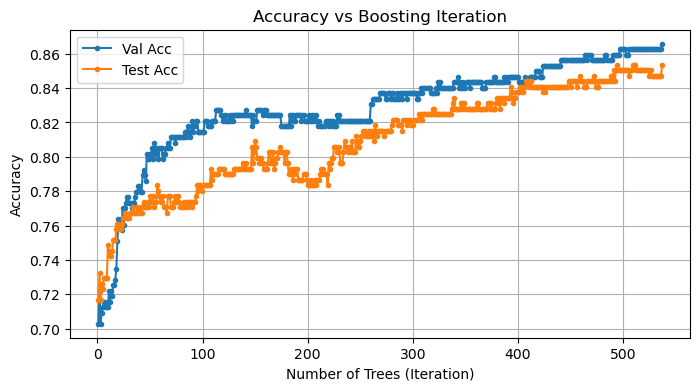

In [269]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

n_trees = cat_model.tree_count_
test_accs = []
val_accs  = []

for i in range(1, n_trees+1):
    # predict up to tree i
    preds_test = cat_model.predict(X_test,  ntree_end=i).astype(int)
    preds_val  = cat_model.predict(X_val,   ntree_end=i).astype(int)
    
    test_accs.append(accuracy_score(y_test, preds_test))
    val_accs.append (accuracy_score(y_val,   preds_val))

# plot both
plt.figure(figsize=(8,4))
plt.plot(range(1, n_trees+1), val_accs,  marker='.', label='Val Acc')
plt.plot(range(1, n_trees+1), test_accs, marker='.', label='Test Acc')
plt.xlabel("Number of Trees (Iteration)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Boosting Iteration")
plt.legend()
plt.grid(True)
plt.show()


In [59]:
from catboost import get_gpu_device_count
print("Available GPUs:", get_gpu_device_count())


ImportError: cannot import name 'get_gpu_device_count' from 'catboost' (c:\Users\monar\miniconda3\envs\env_torch\Lib\site-packages\catboost\__init__.py)

In [208]:
from catboost import cv, Pool, CatBoostClassifier
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.metrics import accuracy_score

# 0) Your feature matrix X and labels y, plus cat_features list

# 1) Split off 10% for test
X_tmp, X_test, y_tmp, y_test = train_test_split(
    x, y, test_size=0.10, random_state=42, stratify=y
)

# 2) Split remaining 90% into 80% train (i.e. 80/90=0.8889) and 10% val (i.e. 10/90=0.1111)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.1111111, random_state=42, stratify=y_tmp
)

# 3) Prepare Pools
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool   = Pool(X_val,   y_val,   cat_features=cat_features)

# 4) Define grid (omit rsm for GPU mode)
param_grid = {
    'iterations':       [300],
    'depth':            [3, 6, 8, 10],
    'learning_rate':    [0.02, 0.05],
    'l2_leaf_reg':      [1, 3, 5],
    'bagging_temperature': [0.2, 0.5, 1.0],
    # 'subsample':        [0.7, 0.8, 1.0],
    'random_strength':  [0.5, 1.0, 2.0]
}

best = {'best_cv_accuracy': 0.0}

# 5) 5‑fold CV grid search on GPU
for p in ParameterGrid(param_grid):
    params = {
        **p,
        'loss_function': 'Logloss',
        'eval_metric':   'Accuracy',
        'verbose':       False,
        'task_type':     'GPU',
        'devices':       '0'
    }

    cv_df = cv(
        train_pool,
        params,
        fold_count=2,
        partition_random_seed=42,
        early_stopping_rounds=100,
        as_pandas=True,
        plot=True
    )

    acc = cv_df['test-Accuracy-mean'].max()
    it  = int(cv_df['test-Accuracy-mean'].idxmax())

    if acc > best['best_cv_accuracy']:
        best = {**params, 'best_iter': it, 'best_cv_accuracy': acc}

    # print(f"→ CV Acc {acc:.4f} @ iter {it} for {p}")

print("\n✅ Best CV run:")
for k, v in best.items():
    print(f"  {k}: {v}")

# 6) Final model: train on train + early stop on val, rollback to best iteration
final_model = CatBoostClassifier(
    iterations           = best['best_iter'],
    depth                = best['depth'],
    learning_rate        = best['learning_rate'],
    l2_leaf_reg          = best['l2_leaf_reg'],
    bagging_temperature  = best['bagging_temperature'],
    # subsample            = best['subsample'],
    random_strength      = best['random_strength'],
    loss_function        = 'Logloss',
    class_weights       = [w0, w1],
    eval_metric          = 'Accuracy',
    use_best_model       = True,
    task_type            = 'GPU',
    devices              = '0',
    random_seed          = 42,
    early_stopping_rounds=30,
    verbose              = 100
)

final_model.fit(train_pool, eval_set=val_pool)

# 7) Evaluate on held‑out test set
preds = final_model.predict(X_test)
test_acc = accuracy_score(y_test, preds)
print(f"\n📊 Held‑out Test Accuracy: {test_acc:.4f}")


ValueError: Found input variables with inconsistent numbers of samples: [1567, 1331]

In [275]:
test2, lists, cat_features = preprocess_appian(test2)
outputs = cat_model.predict_proba(test2[lists])[:,-1]
outputs = (outputs >= 0.52).astype(int)  # try 0.5 to 0.6
submission = pd.DataFrame({'ID': test2['ID'], 'Target': outputs})

In [276]:
submission.to_csv(r'cat-0.csv', index=False)

In [251]:
# Load test data
test = pd.read_csv(r'appian-x-iit-madras-hackathon-april-2025\test.csv')
testo, id_values_t = preprocess_data(test)

# Make predictions on test data
test_predictions_proba = cat_model.predict_proba(testo)[:, 1]
# test_predictions = final_model.predict(testo)
test_predictions = (test_predictions_proba >= 0.60).astype(int)  # Adjust threshold as needed

# Create submission dataframe
submission = pd.DataFrame({
    'ID': id_values_t,
    'Target': test_predictions.astype(int)
})

# Save submission file
submission.to_csv('catboost_hem.csv', index=False)
print("Predictions saved to 'catboost_submission.csv'")

CatBoostError: catboost/libs/data/model_dataset_compatibility.cpp:81: At position 28 should be feature with name Enroll_Day (found Child_Ratio).